EDA (EXPLORATORY DATA ANALYSIS)

# This cell imports all the required Python libraries such as pandas, numpy, matplotlib, seaborn, and others.
# It then loads the dataset from 'merged_dataset.csv' into a pandas DataFrame called df.
# The head() function is used to preview the first few rows of the dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
%matplotlib inline
#loading the csv file
df = pd.read_csv("merged_dataset.csv")
df.head()

,text,label
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger


In [ ]:
# This cell shows the number of rows and columns in the dataset.

In [2]:
df.shape

(15969, 2)

# This cell shows how many missing (NaN) values are present in each column of the dataset.

In [3]:
df.isnull().sum()

text     0
label    0
dtype: int64

# This cell displays all the unique values present in the 'label' column.

In [4]:
df['label'].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

# This cell prints key details about the dataset, including its shape, the first 5 rows,
# column names, missing values per column, and the data types of each column.

In [5]:
# Dataset Info
print("Dataset Shape:", df.shape)
print("First 5 rows:", df.head(5))

print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values per Column:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (15969, 2)
First 5 rows:                                                 text    label
0                              didnt feel humiliated  sadness
1  go feeling hopeless damned hopeful around some...  sadness
2          im grabbing minute post feel greedy wrong    anger
3  ever feeling nostalgic fireplace know still pr...     love
4                                    feeling grouchy    anger

Column Names: ['text', 'label']

Missing Values per Column:
 text     0
label    0
dtype: int64

Data Types:
 text     object
label    object
dtype: object


# This cell creates a count plot of the 'label' column to show how many samples exist for each class,
# ordering them by frequency and adding color for better visualization.

In [6]:
# Class Distribution
plt.figure(figsize=(7,4))
sns.countplot(x='label', data=df, order=df['label'].value_counts().index, palette='coolwarm')
plt.title('Label Distribution')
plt.xticks(rotation=30)

C:\Users\nidhi\AppData\Local\Temp\ipykernel_11056\3833348019.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, order=df['label'].value_counts().index, palette='coolwarm')


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'joy'),
  Text(1, 0, 'sadness'),
  Text(2, 0, 'anger'),
  Text(3, 0, 'fear'),
  Text(4, 0, 'love'),
  Text(5, 0, 'surprise')])

# This cell calculates the word and character count for each text entry, 
# then plots a bar chart showing the average word count for each label to compare text lengths across classes.

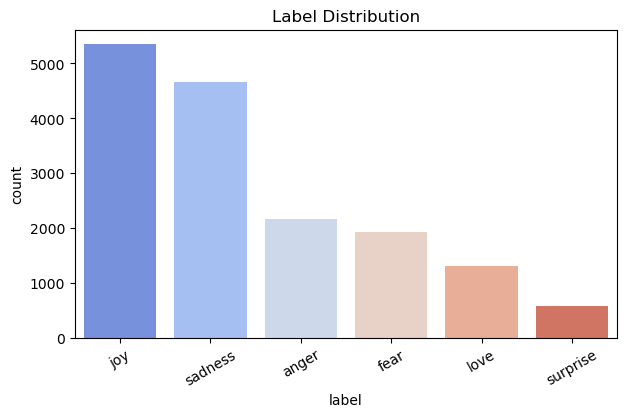

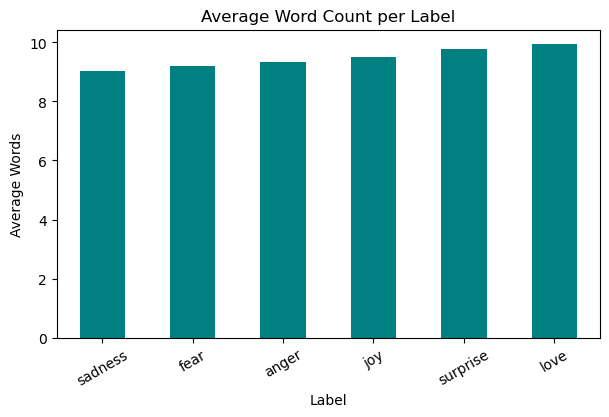

In [7]:
# Text Length Analysis (Bar Graph)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

avg_wc = df.groupby('label')['word_count'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7,4))
avg_wc.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Average Word Count per Label')
ax.set_ylabel('Average Words')
ax.set_xlabel('Label')
plt.xticks(rotation=30)
plt.show()


# Bar plot of average word count per label with values displayed on top. Labels rotated for readability, and the
# plot is styled with teal bars and black edges.

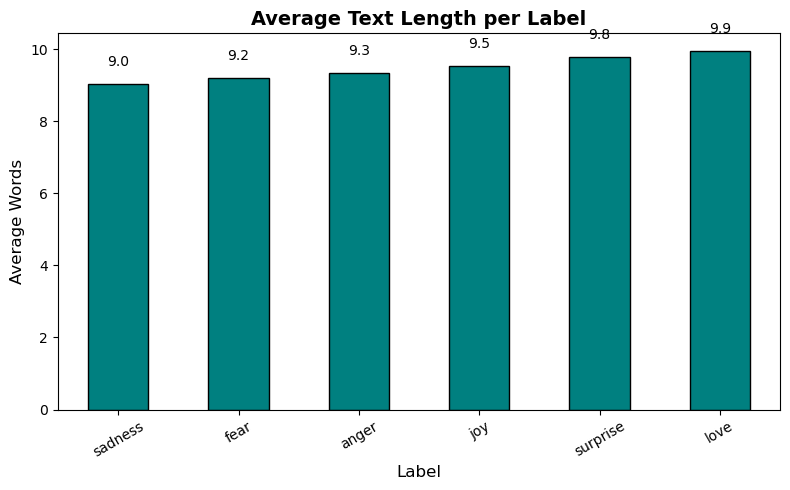

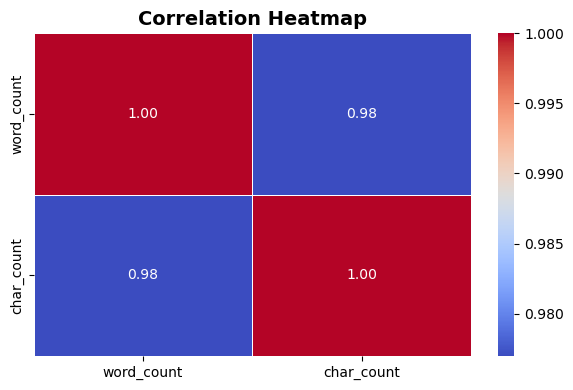

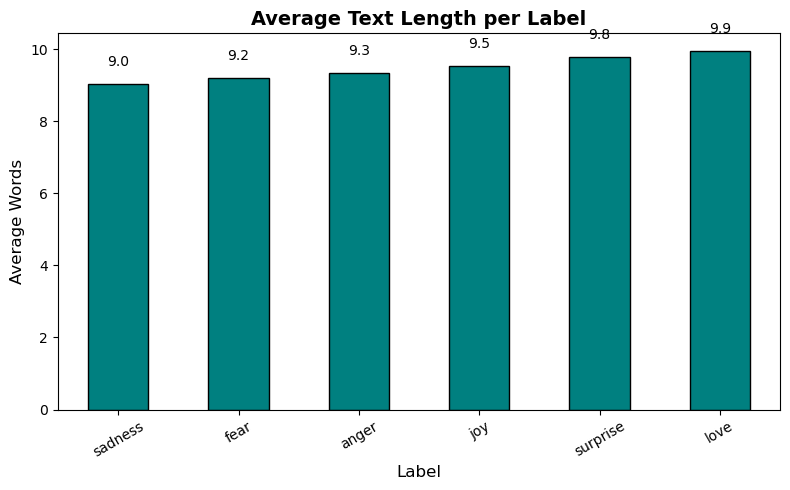

In [16]:
# Average number of words per label 
fig, ax = plt.subplots(figsize=(8,5))
avg_wc.plot(kind='bar', color='teal', edgecolor='black', ax=ax)

ax.set_title('Average Text Length per Label', fontsize=14, fontweight='bold')
ax.set_ylabel("Average Words", fontsize=12)
ax.set_xlabel("Label", fontsize=12)
ax.tick_params(axis='x', rotation=30)

# Add value labels on top of bars
for i, val in enumerate(avg_wc):
    ax.text(i, val + 0.5, f"{val:.1f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Most Common Words per Label
# Finds the top 5 most frequent words for each label after removing punctuation and converting text to lowercase. Prints results label by label.

In [9]:
# Most Common Words per Label
def most_common_words(label, top_n=5):
    texts = df[df['label'] == label]['text']
    words = " ".join(texts).lower().split()
    words = [w.strip(string.punctuation) for w in words if w.strip(string.punctuation)]
    counter = Counter(words)
    return counter.most_common(top_n)

for lbl in df['label'].unique():
    print(f"\nMost Common Words for {lbl}:")
    print(most_common_words(lbl, top_n=5))



Most Common Words for sadness:
[('feel', 3298), ('feeling', 1522), ('like', 864), ('im', 683), ('really', 276)]

Most Common Words for anger:
[('feel', 1457), ('feeling', 719), ('like', 383), ('im', 342), ('really', 124)]

Most Common Words for love:
[('feel', 924), ('feeling', 378), ('like', 304), ('im', 193), ('love', 97)]

Most Common Words for surprise:
[('feel', 353), ('feeling', 209), ('like', 90), ('im', 90), ('amazed', 67)]

Most Common Words for fear:
[('feel', 1209), ('feeling', 741), ('im', 320), ('like', 258), ('little', 149)]

Most Common Words for joy:
[('feel', 3916), ('feeling', 1539), ('like', 1005), ('im', 798), ('really', 309)]


# Selects only the numeric columns from the DataFrame for analysis.

In [10]:
# Select only numeric columns 
numeric_df = df.select_dtypes(include=['number'])

# Calculates the correlation matrix of all numeric columns in the DataFrame.

In [11]:
# Compute correlation matrix
corr = numeric_df.corr()

# Selects numeric columns, computes their correlation matrix, and plots it as a heatmap with annotations for easier visualization.

In [12]:
# Selecting only numeric columns 
numeric_df = df.select_dtypes(include=['number'])
# Computing correlation matrix
corr = numeric_df.corr()
# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()

TOKENIZATION

# Tokenizes the `text` column using NLTK’s `word_tokenize` and stores the result in a new `tokens` column.  
# Prints sample tokens from the first 5 rows.


In [13]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['text'].apply(lambda x: word_tokenize(str(x)))

print("Sample tokens from first 5 rows:")
for i, row in enumerate(df['tokens'].head(), start=1):
    print(f"Row {i}: {row}")


Sample tokens from first 5 rows:
Row 1: ['didnt', 'feel', 'humiliated']
Row 2: ['go', 'feeling', 'hopeless', 'damned', 'hopeful', 'around', 'someone', 'cares', 'awake']
Row 3: ['im', 'grabbing', 'minute', 'post', 'feel', 'greedy', 'wrong']
Row 4: ['ever', 'feeling', 'nostalgic', 'fireplace', 'know', 'still', 'property']
Row 5: ['feeling', 'grouchy']


# Counts the number of missing (null) values in each column of the DataFrame.

In [14]:
df.isnull().sum()

text          0
label         0
word_count    0
char_count    0
tokens        0
dtype: int64